# Bayesian phylogenetic inference with discrete BFFG

This notebook uses the v3 discrete BFFG sweeps to infer latent node states on a rooted tree from noisy leaf observations. The model is intentionally small: every edge uses the same one-step normal transition, so the linear auxiliary is also the true transition and the guided samples are exact up to Monte Carlo error.

We will:

1. Build a tree from a Newick literal.
2. Simulate latent states and noisy leaf observations.
3. Run `discrete_bf_sweep` to push leaf evidence to the root.
4. Sample complete latent trees with `discrete_fg_sweep`.
5. Compare the posterior mean with the deterministic `phylo_mean` estimator.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import hyperiax as hx
from hyperiax.prebuilt import phylo_mean
from hyperiax.prebuilt.bffg import (
    discrete_bf_sweep,
    discrete_fg_sweep,
    discrete_forward_sweep,
    discrete_schema,
    init_discrete_tree,
)

jax.config.update("jax_enable_x64", True)

## 1. Tree and schema

`hx.from_newick` returns a `Tree` whose topology carries the rooted BFS order and node names. We pass the BFFG schema as extra fields; `from_newick` also keeps an `edge_length` field, which we use later for the deterministic mean comparison.

In [2]:
PRIMATE_NEWICK = """
(
  Human:1.0,
  Chimpanzee:1.0,
  (
    Gorilla:1.0,
    (Orangutan:1.0, Gibbon:1.0)AsianApes:1.0
  )GreatApes:1.0,
  (Macaque:1.0, Baboon:1.0)OldWorldMonkeys:1.0
)Primates;
"""

D = 1
schema = {**discrete_schema(D), "estimated_value": (D,)}
tree = hx.from_newick(PRIMATE_NEWICK, schema=schema)
topo = tree.topology

# This tutorial uses a unit-edge model. Set edge lengths to one so the
# deterministic phylo_mean comparison uses the same branch weights.
tree = tree.set(edge_length=jnp.ones(topo.size))

leaf_idx = np.where(topo.is_leaf)[0]
leaf_names = [topo.names[i] for i in leaf_idx]
print(f"nodes: {topo.size}, leaves: {len(leaf_idx)}")
print("leaves:", ", ".join(leaf_names))

nodes: 11, leaves: 7
leaves: Human, Chimpanzee, Gorilla, Macaque, Baboon, Orangutan, Gibbon


## 2. Linear normal edge model

For each edge, the latent child state is

$$X_c \mid X_p = x \sim N(x, \sigma^2 I).$$

The BFFG auxiliary has call signature `(anchor, params)`. Because this model is already linear, the callables ignore the anchor.

In [3]:
SIGMA_SQ = 1.0
OBS_VAR = 0.08
ROOT_TRUTH = jnp.array([0.4])
PARAMS = {"sigma_sq": jnp.array(SIGMA_SQ)}


def mean_fn(x_parent, params):
    return x_parent


def covar_fn(x_parent, params):
    return params["sigma_sq"] * jnp.eye(D, dtype=x_parent.dtype)


def prxy_scale_fn(anchor, params):
    return jnp.eye(D, dtype=anchor.dtype)


def prxy_shift_fn(anchor, params):
    return jnp.zeros((D,), dtype=anchor.dtype)


def prxy_covar_fn(anchor, params):
    return params["sigma_sq"] * jnp.eye(D, dtype=anchor.dtype)

## 3. Simulate observations

`discrete_forward_sweep` is a down-sweep. The root is pinned first, and every non-root node consumes its own pre-stored standard normal `z`.

In [4]:
key = jax.random.PRNGKey(7)
key_path, key_obs, key_samples = jax.random.split(key, 3)

forward = discrete_forward_sweep(mean_fn, covar_fn)
truth = tree.at[topo.is_root].set(val=ROOT_TRUTH[None, :])
truth = truth.set(z=jax.random.normal(key_path, (topo.size, D)))
truth = forward(truth, params=PARAMS)

leaf_truth = truth.val[topo.is_leaf]
leaf_obs = leaf_truth + jnp.sqrt(OBS_VAR) * jax.random.normal(key_obs, leaf_truth.shape)

for name, latent, obs in zip(leaf_names, leaf_truth[:, 0], leaf_obs[:, 0]):
    print(f"{name:15s} latent={float(latent): .3f}  obs={float(obs): .3f}")

Human           latent=-0.754  obs=-0.901
Chimpanzee      latent= 0.354  obs= 0.264
Gorilla         latent= 2.133  obs= 2.336
Macaque         latent= 0.115  obs= 0.199
Baboon          latent=-0.372  obs=-0.430
Orangutan       latent= 0.305  obs= 0.152
Gibbon          latent= 0.678  obs= 0.783


## 4. Backward filter

`init_discrete_tree` converts noisy leaf observations into canonical leaf messages and seeds the anchor field. The backward filter then pulls every child message through the auxiliary transition and sums messages at each parent.

In [5]:
obs_tree = init_discrete_tree(tree, leaf_obs, OBS_VAR, d=D)

bf = discrete_bf_sweep(prxy_scale_fn, prxy_shift_fn, prxy_covar_fn)
up_out = bf(obs_tree, params=PARAMS)

root_prec = up_out.prec[0]
root_ptnl = up_out.ptnl[0]
root_post_mean = jnp.linalg.solve(root_prec, root_ptnl)
root_post_covar = jnp.linalg.inv(root_prec)

print(f"root posterior mean: {float(root_post_mean[0]): .3f}")
print(f"root posterior sd:   {float(jnp.sqrt(root_post_covar[0, 0])): .3f}")
print(f"true root value:     {float(ROOT_TRUTH[0]): .3f}")

root posterior mean:  0.094
root posterior sd:    0.567
true root value:      0.400


## 5. Forward-guided posterior samples

The root message is the marginal posterior for the root under a flat root prior. We first sample the root from that one-dimensional normal and then run `discrete_fg_sweep` top-down to sample the rest of the latent tree.

In [6]:
fg = discrete_fg_sweep(
    mean_fn,
    covar_fn,
    prxy_scale_fn,
    prxy_shift_fn,
    prxy_covar_fn,
)
root_chol = jnp.linalg.cholesky(root_post_covar)


def one_sample(sample_key):
    key_root, key_noise = jax.random.split(sample_key)
    root = root_post_mean + root_chol @ jax.random.normal(key_root, (D,))
    t = up_out.at[topo.is_root].set(val=root[None, :])
    t = t.set(z=jax.random.normal(key_noise, (topo.size, D)))
    return fg(t, params=PARAMS).val


sample_keys = jax.random.split(key_samples, 512)
samples = jax.vmap(one_sample)(sample_keys)
post_mean = samples.mean(axis=0).squeeze(-1)
post_sd = samples.std(axis=0).squeeze(-1)

print(f"mean absolute leaf error: {float(jnp.mean(jnp.abs(post_mean[topo.is_leaf] - leaf_obs[:, 0]))):.3f}")
print(f"posterior sd range:       {float(post_sd.min()):.3f} to {float(post_sd.max()):.3f}")

mean absolute leaf error: 0.049
posterior sd range:       0.267 to 0.672


Plotting the posterior mean and one-standard-deviation bands shows the uncertainty contracts near observed leaves and is wider at internal nodes.

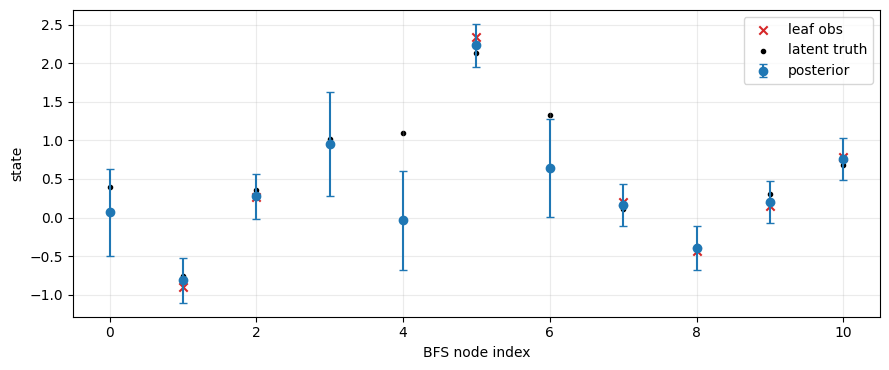

In [7]:
x = np.arange(topo.size)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.errorbar(x, np.asarray(post_mean), yerr=np.asarray(post_sd), fmt="o", capsize=3, label="posterior")
ax.scatter(leaf_idx, np.asarray(leaf_obs[:, 0]), marker="x", color="tab:red", label="leaf obs")
ax.scatter(x, np.asarray(truth.val[:, 0]), marker=".", color="black", label="latent truth")
ax.set_xlabel("BFS node index")
ax.set_ylabel("state")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()

## 6. Deterministic mean comparison

`phylo_mean` is a simple edge-weighted averaging sweep. With unit edge lengths it matches a quick deterministic baseline, while BFFG gives full posterior uncertainty and samples every latent node.

In [8]:
mean_tree = tree.at[topo.is_leaf].set(estimated_value=leaf_obs)
mean_out = phylo_mean()(mean_tree)

rows = []
for node in range(topo.size):
    if topo.is_leaf[node]:
        continue
    name = topo.names[node] or f"node_{node}"
    rows.append((node, name, float(mean_out.estimated_value[node, 0]), float(post_mean[node]), float(post_sd[node])))

print("node  name              phylo_mean  bffg_mean  bffg_sd")
for node, name, det, mean, sd in rows:
    print(f"{node:4d}  {name:16s} {det:10.3f} {mean:10.3f} {sd:8.3f}")

node  name              phylo_mean  bffg_mean  bffg_sd
   0  Primates              0.162      0.068    0.565
   3  GreatApes             1.402      0.953    0.672
   4  OldWorldMonkeys      -0.115     -0.036    0.637
   6  AsianApes             0.467      0.643    0.631


## Takeaways

- `discrete_schema` declares all fields needed by the discrete BFFG pipeline.
- `init_discrete_tree` seeds canonical leaf messages from noisy observations.
- `discrete_bf_sweep` is the bottom-up evidence pass.
- `discrete_fg_sweep` is the top-down posterior sampler once the root state is sampled or pinned.
- Nonlinear models use the same sweeps, but iterate `discrete_bf_sweep` with `discrete_refine_anchor` before sampling.